# Figure 5: External Contextualization

Here we show an example of how to contextualize an external dataset into the LINCS space
- Cosine distance distributions between embeddings derived from an external dataset (GSE51212) and LINCS compound embeddings
- Top ranking of each of the contextualized embeddings vs all posibilities


In [ ]:
import pandas as pd
import scanpy as sc
import pickle
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Distributions of new compound

In [ ]:
adata_external = sc.read('./LINCS_scGPT_embeddings/Data/Intermediate_files/GSE51212_zeroimp_hq_50.h5ad')
adata_lincs = sc.read_h5ad('./LINCS_scGPT_embeddings/02_Obtain_Embeddings/embeddings_HQ.h5ad')

adata_lincs = adata_lincs[adata_lincs.obs.pert_type == 'trt_cp'].copy()

In [5]:
adata_external.obs.Treatment

GSM
GSM1240545         DMSO
GSM1240546         DMSO
GSM1240547         DMSO
GSM1240548    ERLOTINIB
GSM1240549    ERLOTINIB
GSM1240550    ERLOTINIB
GSM1240551      AZD6244
GSM1240552      AZD6244
GSM1240553      AZD6244
GSM1240554       BEZ235
GSM1240555       BEZ235
GSM1240556       BEZ235
GSM1240557         DMSO
GSM1240558    ERLOTINIB
GSM1240559    ERLOTINIB
GSM1240560    ERLOTINIB
Name: Treatment, dtype: category
Categories (4, object): ['AZD6244', 'BEZ235', 'DMSO', 'ERLOTINIB']

In [6]:
emb_lincs = adata_lincs.obsm['X_scGPT']
d_lincs = adata_lincs.obs.cmap_name.to_numpy()

emb_external = adata_external.obsm['X_scGPT']
d_external = adata_external.obs.Treatment.to_numpy()

### Explore distances inside the experiment

In [7]:
distances_external = cdist(emb_external,emb_external,  metric='cosine')

### Explore distances between external and LINCS data

In [8]:
d_external_lincs = []
for i in d_external: 
    if i == 'ERLOTINIB':
        d_external_lincs.append('erlotinib')
    elif i == 'DMSO':
        d_external_lincs.append(i)
    elif i == 'BEZ235':
        d_external_lincs.append('NVP-BEZ235')
    elif i == 'AZD6244':
        d_external_lincs.append('selumetinib')

In [9]:
adata_external.obs['Treatment'] = d_external_lincs

In [10]:
distances_external2lincs = cdist(emb_external, emb_lincs,  metric='cosine')


In [11]:
all_distances = np.concatenate(distances_external2lincs)

In [12]:
same_exp_idx = {
    name: np.where(np.asarray(d_external_lincs) == name)[0]
    for name in np.unique(d_external_lincs)
}

In [13]:
exp2dist = {}
for name, idxs in same_exp_idx.items():
    c_emb = adata_lincs[adata_lincs.obs.cmap_name == name].obsm['X_scGPT']
    c_emb_ext = emb_external[idxs]
    exp2dist[name] = np.concatenate(cdist(c_emb, c_emb_ext, metric='cosine'))

In [14]:
# Consistent colors across Fig. 5
COLOR_BG   = sns.color_palette("pastel")[7]   # background / random (orange-ish)
COLOR_QRY  = sns.color_palette("pastel")[0]   # query compound (blue-ish)

TITLE_FS = 10
LABEL_FS = 9
TICK_FS  = 8


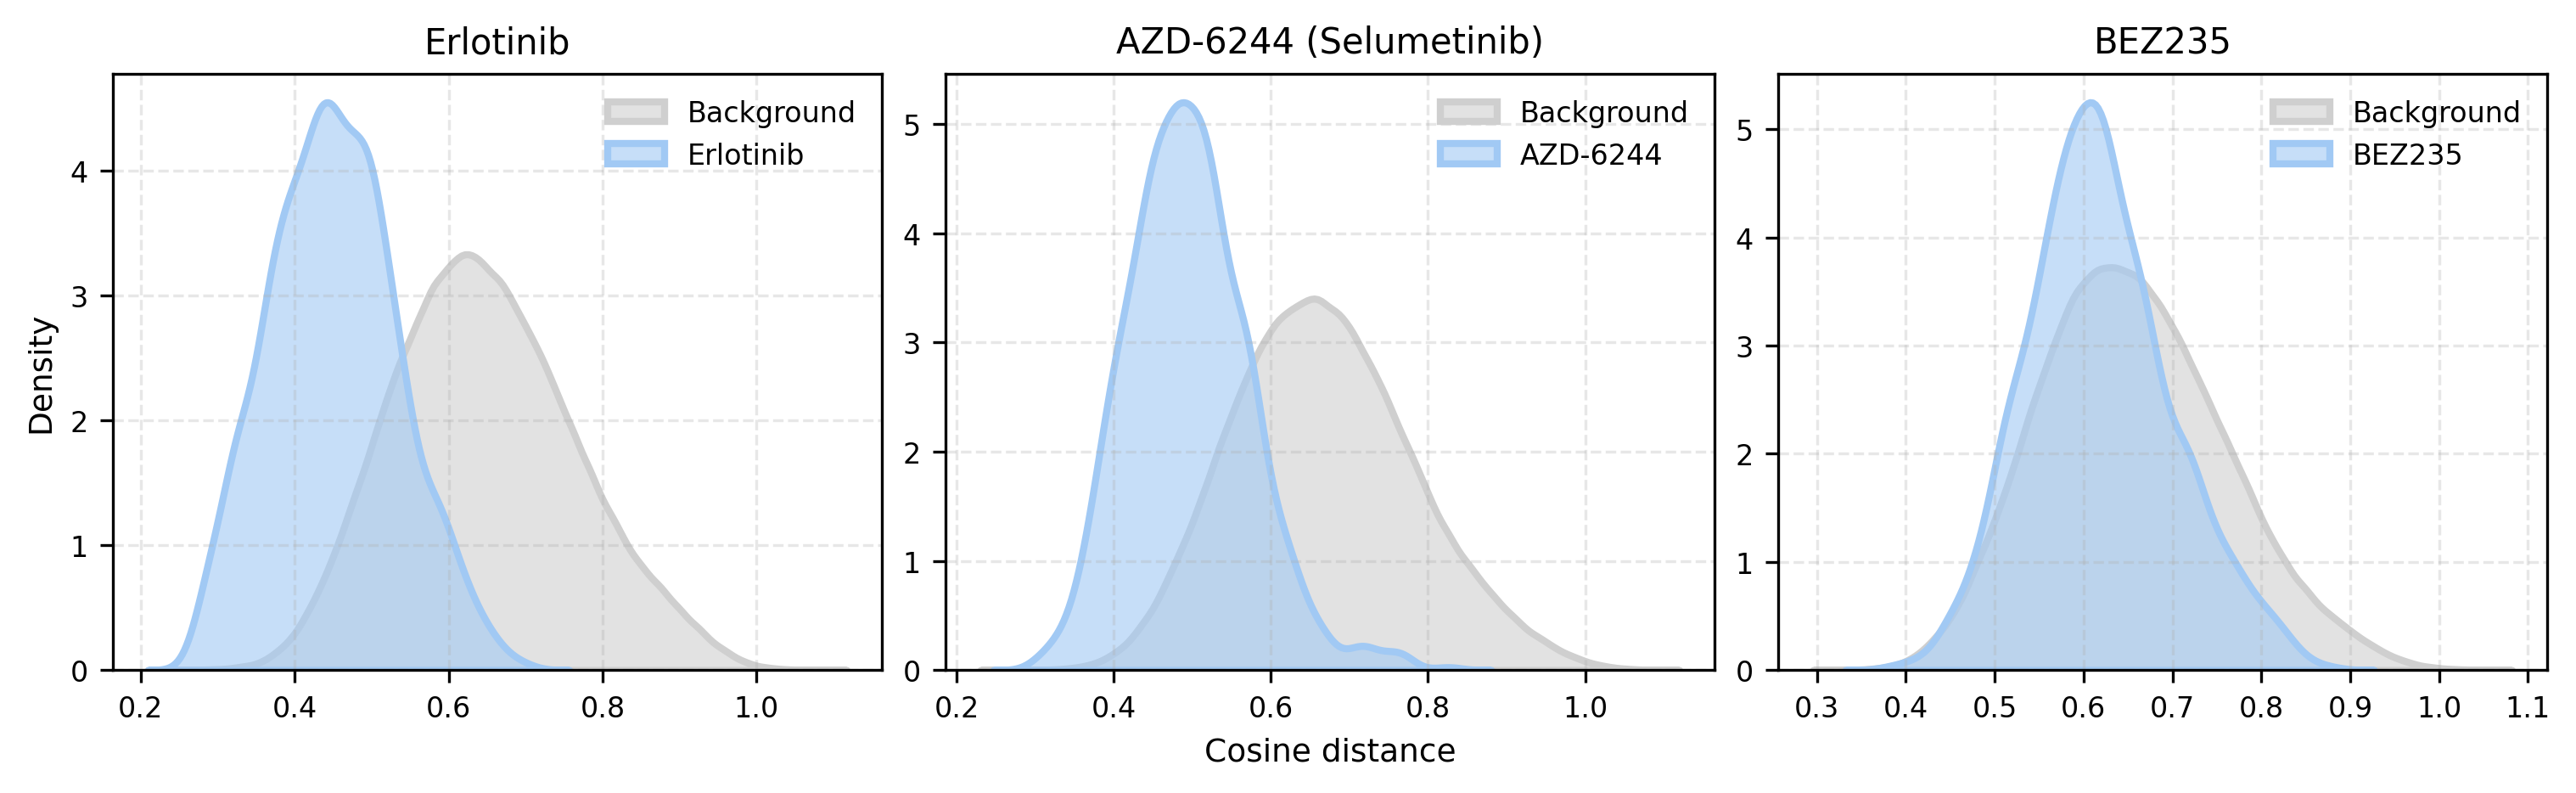

In [15]:
fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 3),
    dpi=300,
    facecolor="white",
    constrained_layout=True
)

# -------------------------
# Panel A
# -------------------------
sns.kdeplot(
    np.concatenate(distances_external2lincs[same_exp_idx['erlotinib']]),
    fill=True, color=COLOR_BG, alpha=0.6, linewidth=2,
    label="Background", ax=axs[0]
)
sns.kdeplot(
    exp2dist['erlotinib'],
    fill=True, color=COLOR_QRY, alpha=0.6, linewidth=2,
    label="Erlotinib", ax=axs[0]
)

axs[0].set_title("Erlotinib", fontsize=TITLE_FS)
axs[0].set_ylabel("Density", fontsize=LABEL_FS)
axs[0].tick_params(labelsize=TICK_FS)
axs[0].legend(frameon=False, fontsize=8)
axs[0].grid(alpha=0.3, ls="--")

# -------------------------
# Panel B
# -------------------------
sns.kdeplot(
    np.concatenate(distances_external2lincs[same_exp_idx['selumetinib']]),
    fill=True, color=COLOR_BG, alpha=0.6, linewidth=2,
    label="Background", ax=axs[1]
)
sns.kdeplot(
    exp2dist['selumetinib'],
    fill=True, color=COLOR_QRY, alpha=0.6, linewidth=2,
    label="AZD-6244", ax=axs[1]
)

axs[1].set_title("AZD-6244 (Selumetinib)", fontsize=TITLE_FS)
axs[1].set_xlabel("Cosine distance", fontsize=LABEL_FS)
axs[1].set_ylabel("")
axs[1].tick_params(labelsize=TICK_FS)
axs[1].legend(frameon=False, fontsize=8)
axs[1].grid(alpha=0.3, ls="--")

# -------------------------
# Panel C
# -------------------------
sns.kdeplot(
    np.concatenate(distances_external2lincs[same_exp_idx['NVP-BEZ235']]),
    fill=True, color=COLOR_BG, alpha=0.6, linewidth=2,
    label="Background", ax=axs[2]
)
sns.kdeplot(
    exp2dist['NVP-BEZ235'],
    fill=True, color=COLOR_QRY, alpha=0.6, linewidth=2,
    label="BEZ235", ax=axs[2]
)

axs[2].set_title("BEZ235", fontsize=TITLE_FS)
axs[2].set_ylabel("")
axs[2].tick_params(labelsize=TICK_FS)
axs[2].legend(frameon=False, fontsize=8)
axs[2].grid(alpha=0.3, ls="--")

plt.show()



##  Where the compound fail 

In [16]:
# Reuse the embeddings, normalized treatment labels, and external-to-LINCS
# distance matrix computed above.

In [17]:
distances_order = distances_external2lincs.argsort()
cmp_order = d_lincs[distances_order]

In [18]:
def unique_preserve_order(row):
    seen = set()
    return np.array([x for x in row if not (x in seen or seen.add(x))], dtype=object)

# Apply row-wise
cmp_order_unique = np.array(
    [unique_preserve_order(row) for row in cmp_order],
    dtype=object
)

In [19]:
cmp2order_list = []
for r in range(len(d_external_lincs)): 
    c_order = cmp_order_unique[r]
    c_where = np.where(c_order == d_external_lincs[r])[0]
    cmp2order_list.append(c_where)

In [20]:
cmp2order_list_min = [i.min() for i in cmp2order_list]

In [24]:
import numpy as np

def get_best_external_examples(
    distances_external2lincs,
    distances_order,
    cmp2order_list_min,
    d_external_lincs,
    compounds_to_plot,
):
    """
    Extract minimal info needed to reproduce ECDF plots for selected compounds,
    without saving/loading from disk.
    """

    out = {}
    d_external_lincs = np.asarray(d_external_lincs)
    cmp2order_list_min = np.asarray(cmp2order_list_min)

    for cmp_name in compounds_to_plot:
        # Indices of external signatures for this compound
        idxs = np.where(d_external_lincs == cmp_name)[0]

        if len(idxs) == 0:
            raise ValueError(f"Compound not found in d_external_lincs: {cmp_name}")

        # Best external signature for this compound = lowest rank among its signatures
        local_best_idx = np.argmin(cmp2order_list_min[idxs])
        best_sig = idxs[local_best_idx]

        min_rank = int(cmp2order_list_min[best_sig])

        best_dist = distances_external2lincs[best_sig][
            distances_order[best_sig][min_rank]
        ]

        out[f"{cmp_name}_dist"] = distances_external2lincs[best_sig].astype(np.float32)
        out[f"{cmp_name}_rank"] = np.int32(min_rank)
        out[f"{cmp_name}_bestdist"] = np.float32(best_dist)

        print(f"Selected {cmp_name}: best signature={best_sig}, rank={min_rank}")

    out["lincs_N"] = np.int32(distances_external2lincs.shape[1])

    return out


compounds_fig = ["erlotinib", "selumetinib", "NVP-BEZ235"]

data = get_best_external_examples(
    distances_external2lincs=distances_external2lincs,
    distances_order=distances_order,
    cmp2order_list_min=cmp2order_list_min,
    d_external_lincs=d_external_lincs,
    compounds_to_plot=compounds_fig,
)

Selected erlotinib: best signature=3, rank=0
Selected selumetinib: best signature=6, rank=3
Selected NVP-BEZ235: best signature=11, rank=59


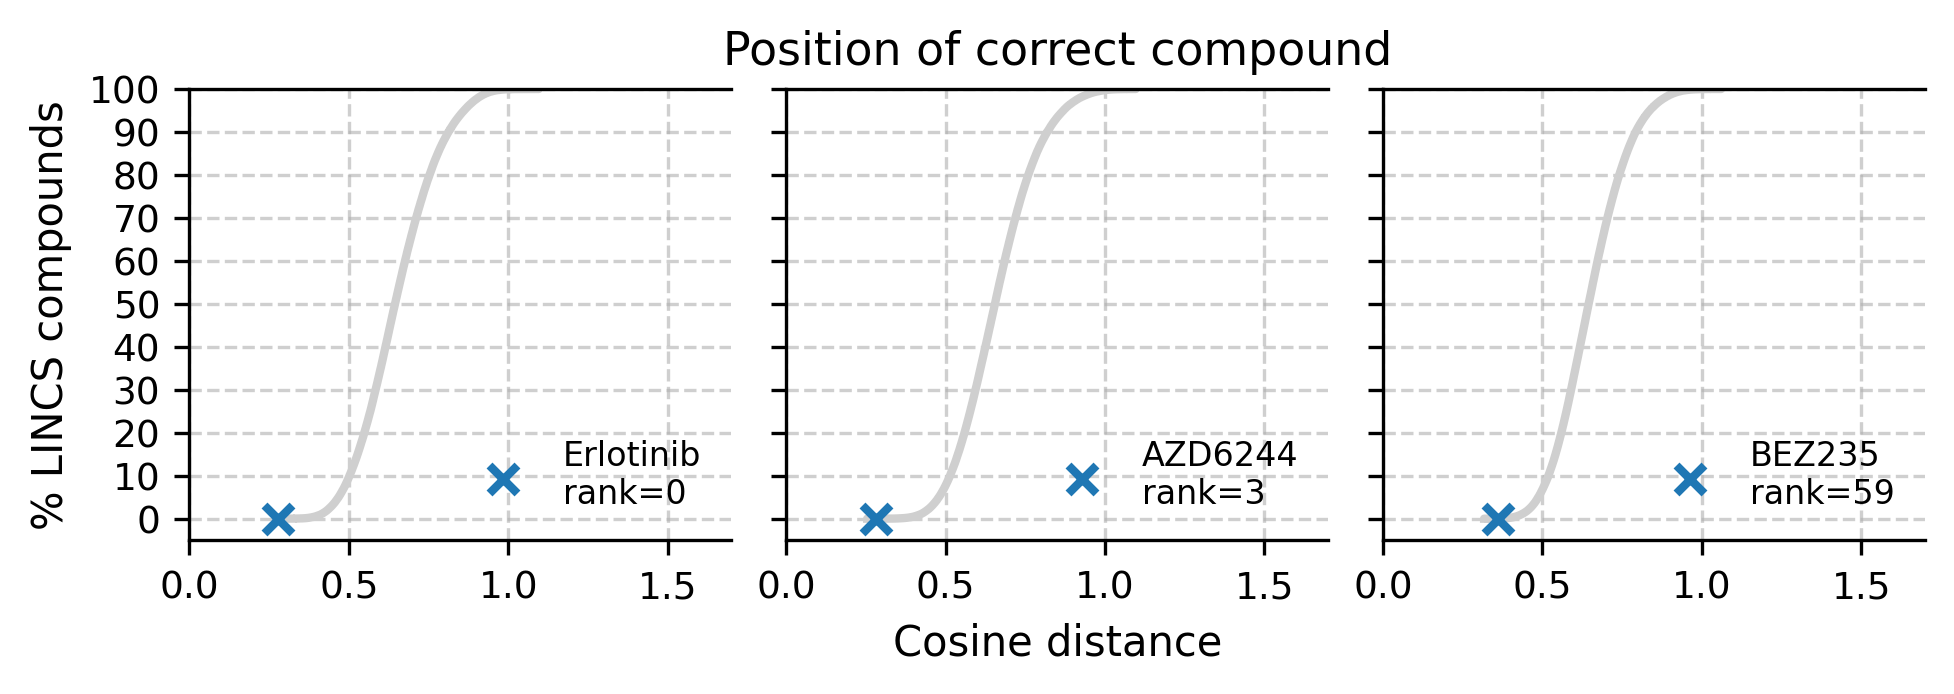

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# consistent colors
C_BG = sns.color_palette("pastel")[7]
C_HI = sns.color_palette("tab10")[0]

TITLE_FS = 11
LABEL_FS = 10
TICK_FS  = 9

def plot_ecdf_example(ax, dist, rank, best_dist, label):
    sns.ecdfplot(x=dist, ax=ax, color=C_BG, lw=2)

    y = rank / len(dist)
    ax.scatter(
        best_dist, y,
        marker='x', s=45, linewidths=2,
        color=C_HI, zorder=10,
        label=f"{label}\nrank={rank}"
    )

    ax.set_xlim(0, 1.7)
    ax.set_ylim(-0.05, 1.0)
    ax.grid(ls="--", alpha=0.6)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=TICK_FS)
    ax.legend(frameon=False, fontsize=8)

# ---- figure ----
fig, axes = plt.subplots(1, 3, figsize=(6.4, 2.2), dpi=300, constrained_layout=True)

# Erlotinib
plot_ecdf_example(
    axes[0],
    data["erlotinib_dist"],
    int(data["erlotinib_rank"]),
    float(data["erlotinib_bestdist"]),
    "Erlotinib"
)
axes[0].set_ylabel("% LINCS compounds", fontsize=LABEL_FS)
axes[0].set_yticks(np.arange(0, 1.1, 0.1))
axes[0].set_yticklabels((np.arange(0, 1.1, 0.1) * 100).astype(int), fontsize=TICK_FS)

# Selumetinib / AZD6244
plot_ecdf_example(
    axes[1],
    data["selumetinib_dist"],
    int(data["selumetinib_rank"]),
    float(data["selumetinib_bestdist"]),
    "AZD6244"
)
axes[1].set_yticklabels([])
axes[1].set_yticks(np.arange(0, 1.1, 0.1))
axes[1].set_xlabel("Cosine distance", fontsize=LABEL_FS)
axes[1].set_title("Position of correct compound", fontsize=TITLE_FS)
axes[1].set_ylabel('')

# BEZ235
plot_ecdf_example(
    axes[2],
    data["NVP-BEZ235_dist"],
    int(data["NVP-BEZ235_rank"]),
    float(data["NVP-BEZ235_bestdist"]),
    "BEZ235"
)
axes[2].set_yticklabels([])
axes[2].set_yticks(np.arange(0, 1.1, 0.1))
axes[2].set_ylabel('')

plt.show()
